# Desafio Técnico Keyrus — Bank Marketing

Data Scientist — desafio de modelagem em Python.

**Objetivo:** prever se um cliente vai assinar um depósito a prazo (`y`), a partir do dataset [Bank Marketing](https://www.kaggle.com/datasets/abdelazizsami/bank-marketing/data) (Kaggle), réplica do dataset público UCI de Moro et al. (2011).

Roteiro seguido (ver `docs/Teste_Modelagem_Python.pdf`): EDA → pré-processamento → modelagem → avaliação → interpretação → uso em produção.

## 1. Análise Exploratória de Dados (EDA)

A partir daqui, `bank_full_df` (45.211 linhas) passa a ser o dataset principal de todo o desafio — inclusive nas próximas tarefas (pré-processamento e modelagem). `bank.csv` é carregado nesta mesma subseção (1.1) mas não é usado no restante da EDA: a própria documentação do dataset (`docs/bank-names.txt`) o descreve como uma amostra de 10% pensada só para testar algoritmos computacionalmente caros (ex. SVM), não como base de um projeto completo — e mais dados reais disponíveis tendem a gerar uma EDA e um modelo mais robustos.

### 1.1 Carregamento dos dados e estatísticas básicas

Leitura direta do Kaggle via [`kagglehub`](https://github.com/Kaggle/kagglehub), sem baixar/versionar os CSVs no repositório.

O dataset traz dois arquivos (ver `docs/bank-names.txt`):
- `bank-full.csv`: todos os 45.211 exemplos.
- `bank.csv`: amostra de 10% (4.521 exemplos).

**Pré-requisito:** credenciais do Kaggle configuradas (`~/.kaggle/kaggle.json` ou variável `KAGGLE_API_TOKEN`). Sem isso, o download abaixo falha na autenticação.

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

RANDOM_SEED = 42  # usada em todas as etapas do notebook que envolvam aleatoriedade

DATASET = "abdelazizsami/bank-marketing"

In [2]:
# O dataset original (Moro et al., 2011) usa ';' como separador de campos.
bank_full_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "bank-full.csv",
    pandas_kwargs={"sep": ";"},
)

bank_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "bank.csv",
    pandas_kwargs={"sep": ";"},
)

# 16 atributos de entrada + 1 alvo (y) = 17 colunas esperadas.
for nome, df in [("bank-full.csv", bank_full_df), ("bank.csv", bank_df)]:
    assert df.shape[1] == 17, (
        f"{nome}: esperadas 17 colunas, encontradas {df.shape[1]} — "
        "verifique o separador do CSV."
    )
    print(f"{nome}: {df.shape[0]} linhas, {df.shape[1]} colunas")

bank-full.csv: 45211 linhas, 17 colunas
bank.csv: 4521 linhas, 17 colunas


In [3]:
bank_full_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [5]:
print(f"Formato: {bank_full_df.shape[0]} linhas x {bank_full_df.shape[1]} colunas\n")
bank_full_df.info()

Formato: 45211 linhas x 17 colunas

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [6]:
# Listas reutilizadas nas subseções seguintes
NUM_COLS = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
CAT_COLS = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
assert set(NUM_COLS) | set(CAT_COLS) | {"y"} == set(bank_full_df.columns)

bank_full_df[NUM_COLS].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
bank_full_df[CAT_COLS + ["y"]].describe()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


### 1.2 Valores ausentes

In [8]:
# docs/bank-names.txt afirma "Missing Attribute Values: None" — e de fato não há NaN.
bank_full_df.isnull().sum().rename("nulos").to_frame()

,nulos
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [9]:
# Mas "unknown" é usado como valor em 4 colunas categóricas — ausência disfarçada de categoria.
unknown_cols = ["job", "education", "contact", "poutcome"]
unknown_summary = pd.DataFrame(
    {"unknown_qtd": [(bank_full_df[c] == "unknown").sum() for c in unknown_cols]},
    index=unknown_cols,
)
unknown_summary["unknown_pct"] = (unknown_summary["unknown_qtd"] / len(bank_full_df) * 100).round(1)
unknown_summary

,unknown_qtd,unknown_pct
job,288,0.6
education,1857,4.1
contact,13020,28.8
poutcome,36959,81.7


In [10]:
# pdays = -1 é outro sentinela de ausência: "cliente nunca contatado antes".
# Consistência esperada: pdays == -1 deve coincidir com previous == 0 e poutcome == "unknown".
pdays_never_contacted = (bank_full_df["pdays"] == -1).sum()
previous_zero = (bank_full_df["previous"] == 0).sum()
poutcome_unknown = (bank_full_df["poutcome"] == "unknown").sum()

print(f"pdays == -1 (nunca contatado antes): {pdays_never_contacted}")
print(f"previous == 0 (nenhum contato anterior): {previous_zero}")
print(f"poutcome == 'unknown':                {poutcome_unknown}")

pdays == -1 (nunca contatado antes): 36954
previous == 0 (nenhum contato anterior): 36954
poutcome == 'unknown':                36959


**Abordagem adotada:** não há `NaN` no sentido literal, mas `job`, `education`, `contact` e `poutcome` usam `"unknown"` como valor, e `pdays = -1` é um sentinela para "nunca contatado antes" — não são ausências aleatórias, têm significado próprio (ex.: `poutcome == "unknown"` é consistente com `previous == 0`, cliente que nunca foi contatado numa campanha anterior). Por isso, a decisão é **manter esses valores como categoria/sentinela própria**, sem imputação ou remoção de linhas. O tratamento formal (encoding) fica para a tarefa de Pré-processamento, a próxima do roteiro.

### 1.3 Visualização e análise de dados numéricos e categóricos

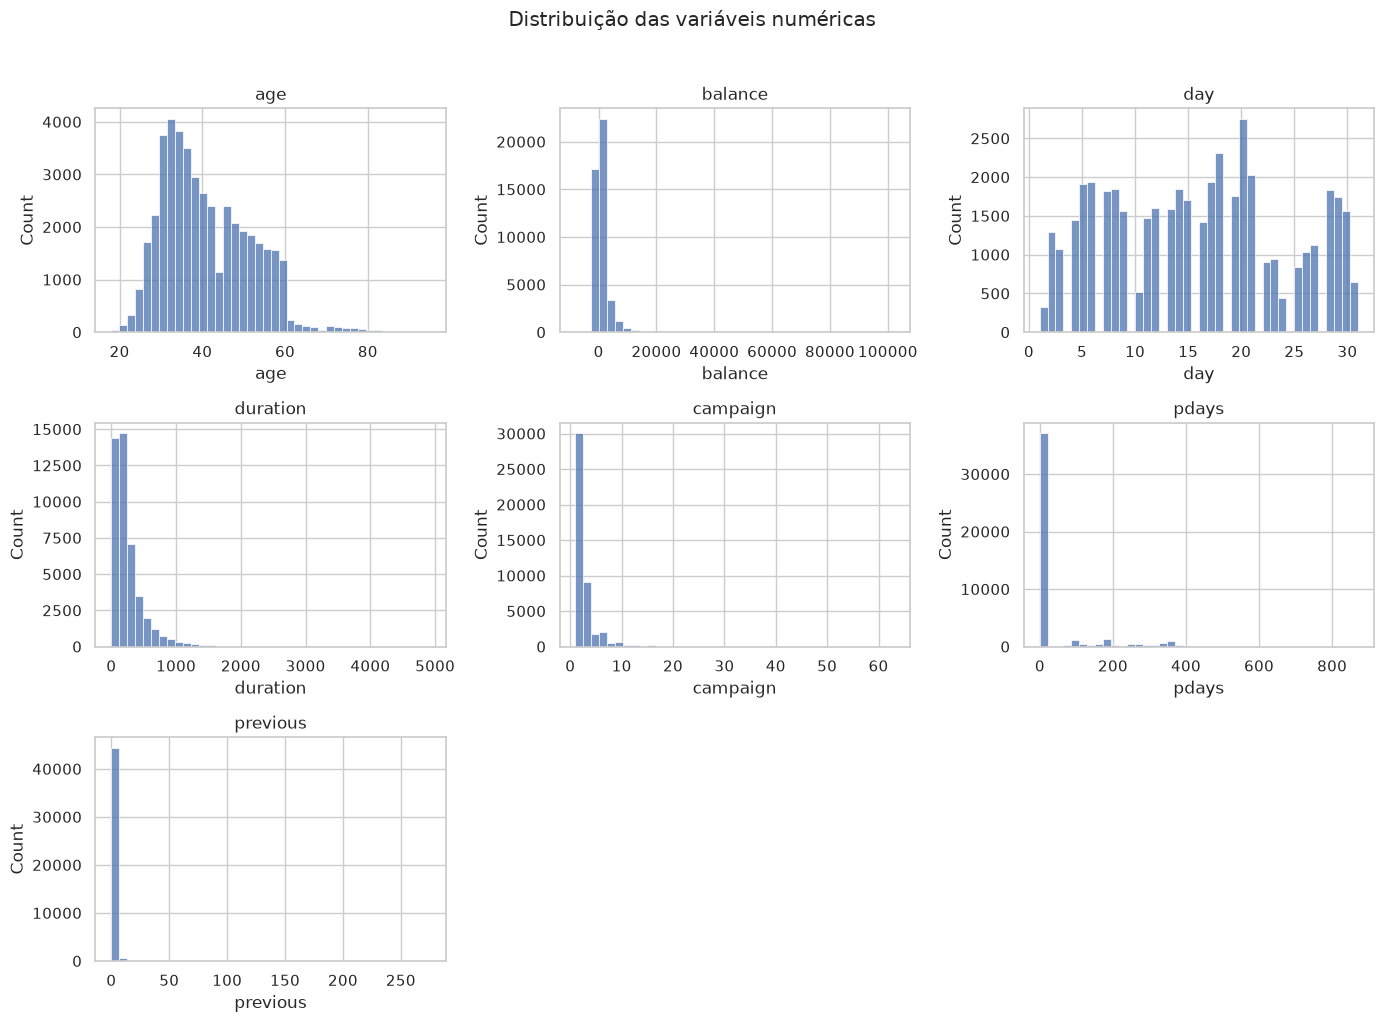

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, NUM_COLS):
    sns.histplot(bank_full_df[col], bins=40, ax=ax)
    ax.set_title(col)
for ax in axes[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Distribuição das variáveis numéricas", y=1.02)
fig.tight_layout()
plt.show()

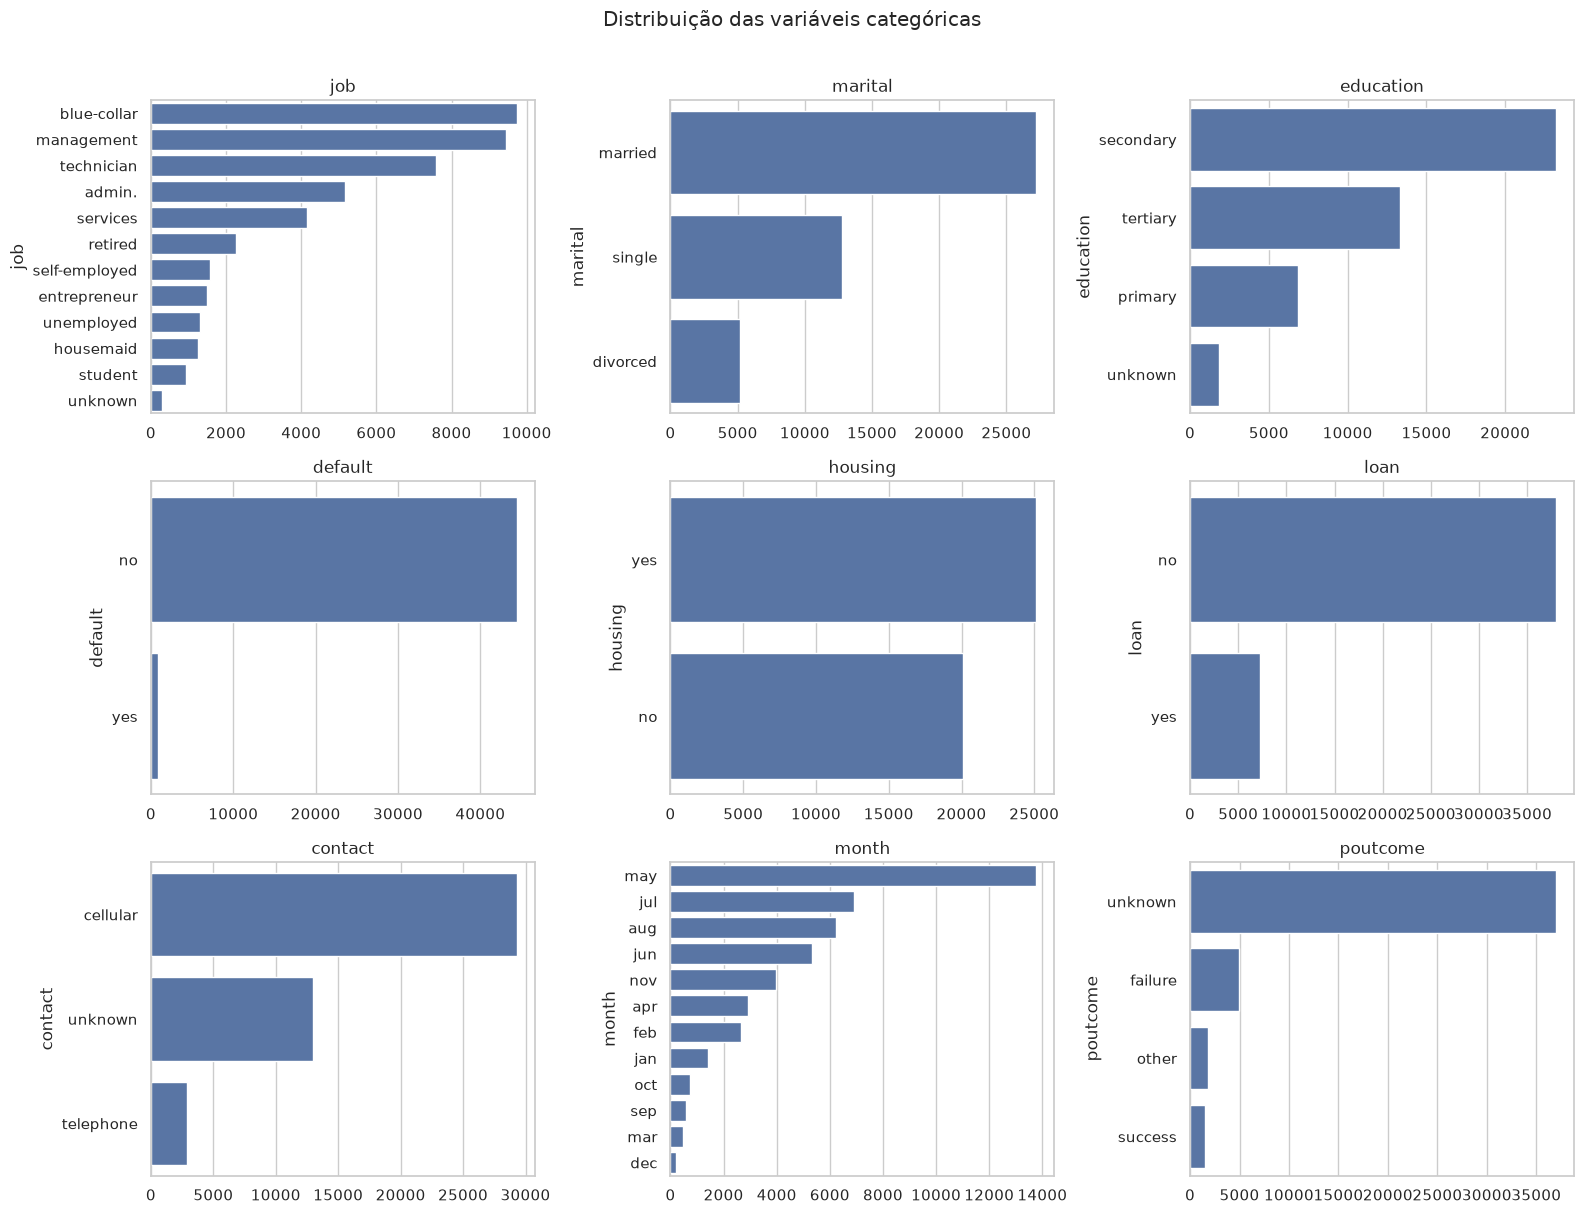

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    order = bank_full_df[col].value_counts().index
    sns.countplot(data=bank_full_df, y=col, order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes[len(CAT_COLS):]:
    ax.axis("off")
fig.suptitle("Distribuição das variáveis categóricas", y=1.01)
fig.tight_layout()
plt.show()

Distribuição de y:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


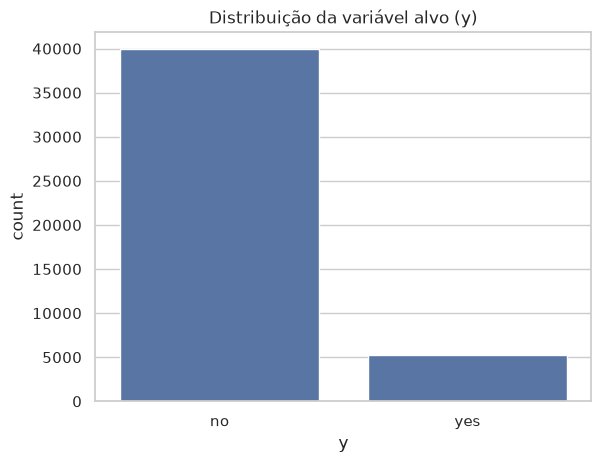

In [13]:
y_dist = bank_full_df["y"].value_counts(normalize=True).mul(100).round(1)
print(f"Distribuição de y:\n{y_dist}")

sns.countplot(data=bank_full_df, x="y")
plt.title("Distribuição da variável alvo (y)")
plt.show()

**Principais observações:** `y` é bastante desbalanceado (~88% "no" vs. ~12% "yes") — relevante para a escolha de métricas na etapa de avaliação. `balance`, `duration` e `campaign` têm cauda longa à direita (poucos clientes com valores bem acima da média). Em `job`, `education`, `contact`, `month` e `poutcome` algumas categorias concentram a maior parte das observações (ex. a maioria dos contatos ocorre em maio).

### 1.4 Relação entre os recursos e a variável alvo (y)

In [14]:
# y codificada em binário só para fins de análise (correlação/agregações) — não altera bank_full_df.
y_binary = bank_full_df["y"].map({"no": 0, "yes": 1})
baseline_rate = y_binary.mean() * 100
print(f"Taxa de conversão geral (baseline): {baseline_rate:.1f}%")

Taxa de conversão geral (baseline): 11.7%


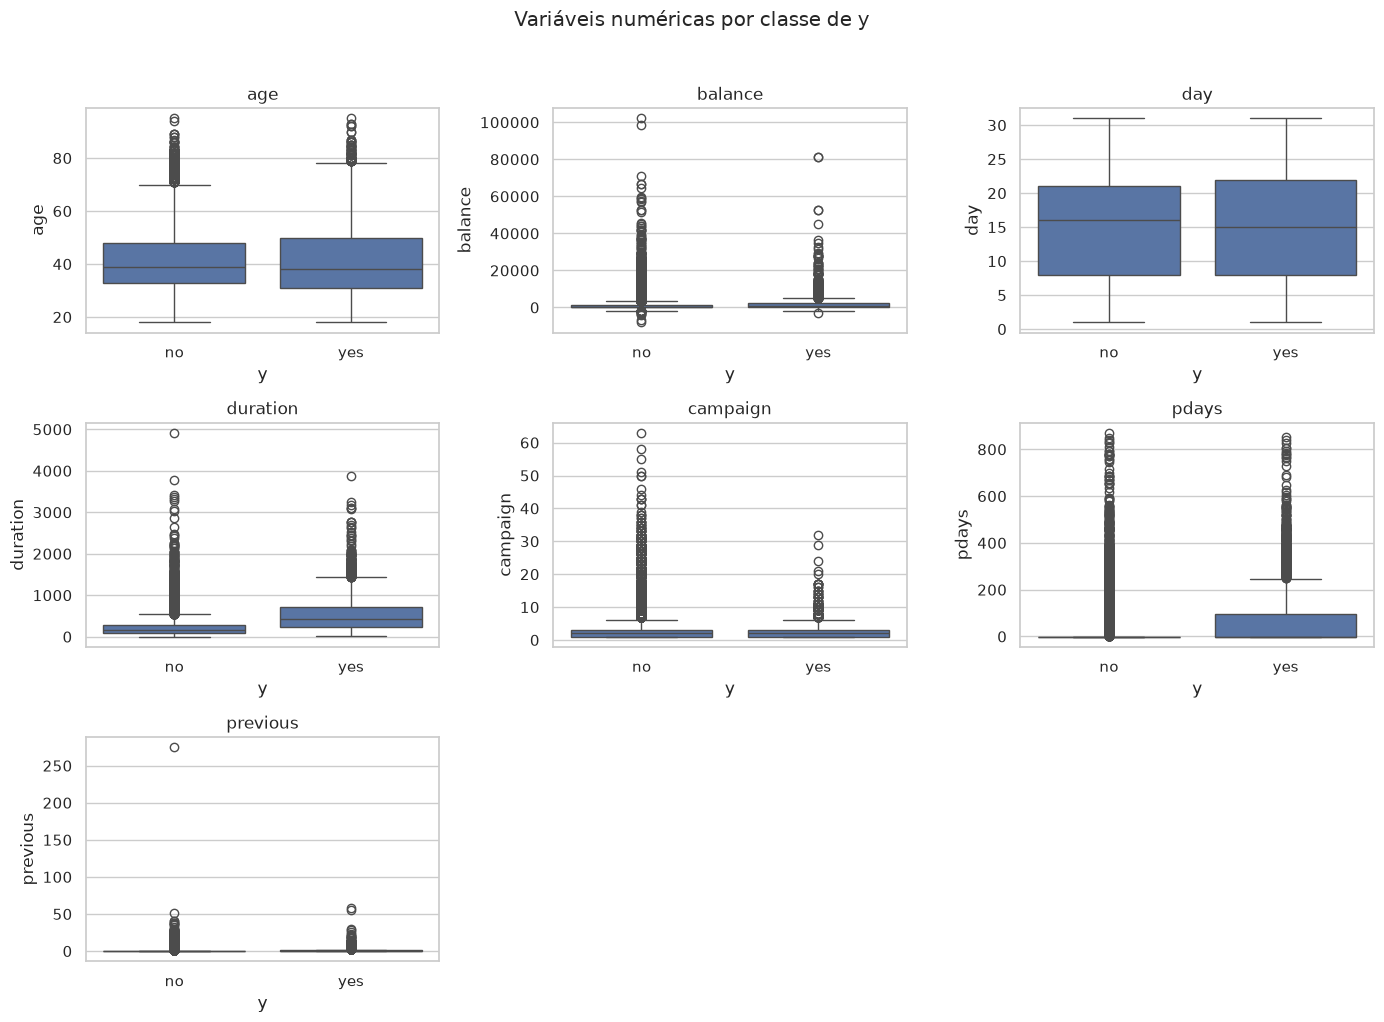

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=bank_full_df, x="y", y=col, ax=ax)
    ax.set_title(col)
for ax in axes[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Variáveis numéricas por classe de y", y=1.02)
fig.tight_layout()
plt.show()

In [16]:
corr_with_y = (
    bank_full_df[NUM_COLS]
    .assign(y=y_binary)
    .corr()["y"]
    .drop("y")
    .sort_values(key=abs, ascending=False)
)
corr_with_y.to_frame("correlação com y")

,correlação com y
duration,0.394521
pdays,0.103621
previous,0.093236
campaign,-0.073172
balance,0.052838
day,-0.028348
age,0.025155


**Atenção — vazamento de dado (*data leakage*) em `duration`:** é a variável mais fortemente relacionada a `y`, tanto na correlação quanto nos boxplots acima. Mas `duration` só é conhecida *depois* que a ligação termina — no momento de decidir quem contatar, esse valor não existe. Usá-la como estava aqui deixaria o modelo com um desempenho artificialmente alto e inútil na prática. Vou retomar esse ponto nas tarefas de Pré-processamento, Modelagem e Uso em produção (ex.: treinar/comparar um modelo sem `duration` para uso realista).

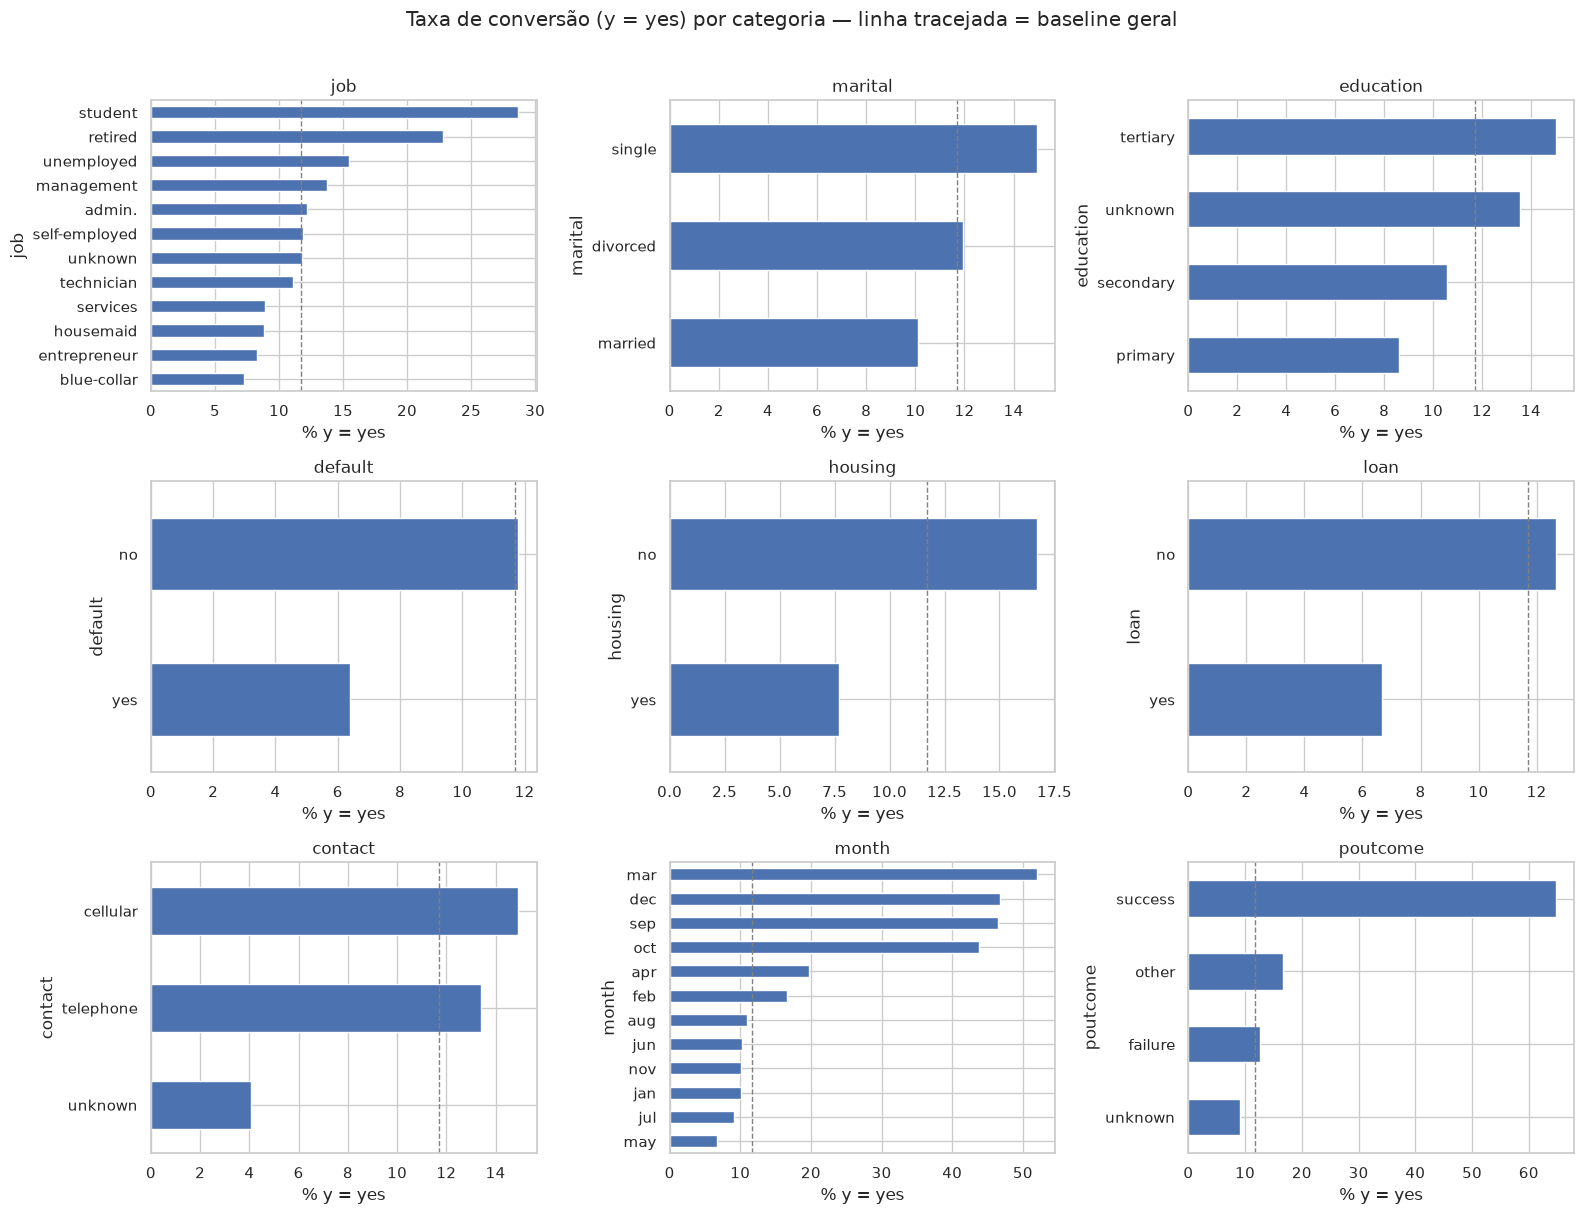

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    rate = bank_full_df.groupby(col)["y"].apply(lambda s: (s == "yes").mean() * 100).sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.axvline(baseline_rate, color="grey", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("% y = yes")
for ax in axes[len(CAT_COLS):]:
    ax.axis("off")
fig.suptitle("Taxa de conversão (y = yes) por categoria — linha tracejada = baseline geral", y=1.01)
fig.tight_layout()
plt.show()

**Principais observações:** clientes com `poutcome == "success"` (campanha anterior bem-sucedida), `contact == "cellular"`, aposentados/estudantes (`job`), e contatados em meses como março/setembro/outubro/dezembro convertem bem acima do baseline geral. `pdays` e `previous` também se destacam entre as numéricas (ter sido contatado antes, e há pouco tempo, associa-se a maior conversão) — coerente com o padrão visto em `poutcome`.

## 2. Pré-processamento de Dados

**`duration` é excluída do conjunto de features a partir daqui** (e em todas as tarefas seguintes) — conforme o vazamento de dado identificado na Seção 1.4: só é conhecida depois que a ligação termina, então não pode ser usada num modelo realista de produção.

**Nota sobre a ordem de execução:** o roteiro lista primeiro "codificar/normalizar/padronizar" e depois "separar treino/teste". Se o ajuste (`fit`) dos transformadores (`StandardScaler`, `OneHotEncoder`) for feito com a base inteira antes do split, estatísticas do conjunto de teste vazam para o treino — um erro comum de pipeline. Por isso a subseção 2.1 abaixo só define e justifica a estratégia (monta o transformador, sem ajustá-lo); o `fit` de fato só acontece na 2.2, depois do split, usando apenas o treino.

### 2.1 Codificação, normalização e padronização (estratégia e justificativa)

- `default`, `housing`, `loan`: binárias `yes`/`no` → mapeadas para `1`/`0` (uma coluna, sem necessidade de one-hot para 2 categorias).
- `job`, `marital`, `education`, `contact`, `month`, `poutcome`: nominais sem ordem natural inequívoca (inclusive por causa do `"unknown"`, que não é claramente "menor" ou "maior" que as demais categorias) → `OneHotEncoder`.
- Variáveis numéricas (exceto `duration`): `StandardScaler`. Preferido a normalização min-max porque `balance`, `campaign` e `previous` têm outliers fortes (visto na EDA) — min-max é muito sensível a eles, enquanto o z-score é mais robusto e serve bem tanto para modelos lineares/baseados em distância quanto para árvores (que toleram qualquer escala).

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

MODEL_NUM_COLS = [c for c in NUM_COLS if c != "duration"]
BINARY_COLS = ["default", "housing", "loan"]
NOMINAL_COLS = [c for c in CAT_COLS if c not in BINARY_COLS]


def encode_binary_yes_no(df):
    return df.apply(lambda col: col.map({"yes": 1, "no": 0}))


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), MODEL_NUM_COLS),
        (
            "bin",
            FunctionTransformer(encode_binary_yes_no, feature_names_out="one-to-one"),
            BINARY_COLS,
        ),
        # sparse_output=False: permite usar preprocessor.set_output(transform="pandas") na Seção 6.
        ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL_COLS),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

### 2.2 Separação em treino e teste

In [19]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = MODEL_NUM_COLS + BINARY_COLS + NOMINAL_COLS
X = bank_full_df[FEATURE_COLS]
y = y_binary  # reaproveitada da Seção 1.4

# Estratificado por y: dataset desbalanceado (~88%/12%, visto na EDA).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

# Ajuste (fit) só no treino — o teste só é transformado, nunca usado para ajustar o preprocessor.
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

print(f"X_train_proc: {X_train_proc.shape}, X_test_proc: {X_test_proc.shape}")
print(f"Taxa de y=1 — treino: {y_train.mean() * 100:.1f}%, teste: {y_test.mean() * 100:.1f}%")
assert "num__duration" not in feature_names

X_train_proc: (36168, 47), X_test_proc: (9043, 47)
Taxa de y=1 — treino: 11.7%, teste: 11.7%


## 3. Construção de Modelos

A comparação e a otimização abaixo usam **só `X_train_proc`/`y_train`** — `X_test_proc`/`y_test` não são tocados nesta tarefa, ficam reservados para a avaliação final. A métrica usada aqui (ROC-AUC) serve para *selecionar* um modelo de forma rápida e é tolerante ao desbalanceamento de `y`; a discussão completa de métricas de negócio (precisão, recall, limiar de decisão etc., já justificadas) é a próxima tarefa do roteiro (Avaliação do Modelo).

### 3.1 Escolha do modelo (comparação e justificativa)

Candidatos comparados, todos nativos do `scikit-learn` (sem adicionar `xgboost`/`lightgbm`):
- `DummyClassifier` (sempre prevê a classe majoritária): piso ingênuo, ~88,3% de "acerto" de graça — mostra por que acurácia sozinha engana num dataset desbalanceado.
- `LogisticRegression`: baseline linear, simples e interpretável.
- `RandomForestClassifier`: captura não linearidades/interações, robusto para dados tabulares.
- `HistGradientBoostingClassifier`: gradient boosting nativo do sklearn, geralmente forte em dados tabulares.

Os 3 modelos reais usam `class_weight="balanced"` para lidar com o desbalanceamento de `y` (~88%/12%, visto na EDA) sem precisar de reamostragem sintética (evita depender de `imbalanced-learn`/SMOTE).

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

candidates = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED
    ),
    "RandomForestClassifier": RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1
    ),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_SEED
    ),
}

results = []
for nome, modelo in candidates.items():
    scores = cross_val_score(modelo, X_train_proc, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append({"modelo": nome, "roc_auc_medio": scores.mean(), "roc_auc_std": scores.std()})

results_df = pd.DataFrame(results).sort_values("roc_auc_medio", ascending=False).reset_index(drop=True)
results_df

,modelo,roc_auc_medio,roc_auc_std
0,HistGradientBoostingClassifier,0.797301,0.001565
1,RandomForestClassifier,0.778222,0.003996
2,LogisticRegression,0.763671,0.003161
3,DummyClassifier,0.500000,0.000000


**Vencedor: `HistGradientBoostingClassifier`** (ROC-AUC médio ≈ 0,80, acima de `RandomForestClassifier` ≈ 0,78 e `LogisticRegression` ≈ 0,76). O `DummyClassifier` fica em 0,50 — exatamente o esperado de um classificador sem poder discriminativo, reforçando que os ~88% de "acerto" da classe majoritária não significam nada por si só. Sigo para otimizar os hiperparâmetros do `HistGradientBoostingClassifier`.

### 3.2 Treinamento final e otimização de hiperparâmetros

Busca por `RandomizedSearchCV` (em vez de `GridSearchCV`): testar exaustivamente todas as combinações do espaço abaixo seria caro computacionalmente; a amostragem aleatória cobre o espaço de forma eficiente com um número fixo de tentativas (`n_iter`).

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_iter": [100, 200, 300, 500],
    "max_leaf_nodes": [15, 31, 63, 127],
    "min_samples_leaf": [10, 20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_SEED),
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
search.fit(X_train_proc, y_train)

print(f"Melhores hiperparâmetros: {search.best_params_}")
print(f"Melhor ROC-AUC (CV): {search.best_score_:.4f}")

final_model = search.best_estimator_  # reaproveitado nas próximas tarefas (Avaliação, Interpretação, Produção)

Melhores hiperparâmetros: {'min_samples_leaf': 20, 'max_leaf_nodes': 31, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 10.0}
Melhor ROC-AUC (CV): 0.7999


## 4. Avaliação do Modelo

Primeira vez que `X_test_proc`/`y_test` são usados — foram reservados desde a Seção 3 justamente para esta avaliação final, feita uma única vez, sobre dados nunca vistos nem pelo treino nem pela busca de hiperparâmetros. Como prometido na abertura da Seção 3, é aqui que discuto as métricas de negócio e o limiar de decisão.

### 4.1 Avaliação com métricas apropriadas (justificativa)

`y` é desbalanceada (~88% "no" / ~12% "yes", visto na EDA) — e a própria Seção 3 mostrou que um `DummyClassifier` (sempre prevê "no") já cravaria ~88% de acurácia sem nenhum poder preditivo. Por isso, acurácia isolada não serve para julgar o modelo aqui. Métricas escolhidas:

- **Matriz de confusão** e **precisão/recall/F1 da classe positiva** (`classification_report`): mostram concretamente o que o modelo acerta e erra em cada classe, sobretudo na classe minoritária (`y = yes`), que é o cliente que a instituição quer identificar.
- **ROC-AUC** e **PR-AUC (average precision)**: métricas independentes de limiar, que avaliam a qualidade do ranking de probabilidades. PR-AUC entra ao lado do ROC-AUC porque, sob desbalanceamento forte, a curva ROC pode parecer otimista demais — a curva precision-recall foca no desempenho da classe minoritária.

As métricas abaixo usam o limiar padrão (0,5) sobre a probabilidade prevista; a discussão de outros limiares fica para os gráficos da 4.2 e para a tarefa de Uso em Produção.

In [22]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

y_pred = final_model.predict(X_test_proc)
y_proba = final_model.predict_proba(X_test_proc)[:, 1]

print(classification_report(y_test, y_pred, target_names=["no", "yes"]))
print("Matriz de confusão (linhas=real, colunas=previsto):")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.95      0.85      0.89      7985
         yes       0.36      0.65      0.46      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.75      0.68      9043
weighted avg       0.88      0.82      0.84      9043

Matriz de confusão (linhas=real, colunas=previsto):
[[6753 1232]
 [ 374  684]]


In [23]:
test_roc_auc = roc_auc_score(y_test, y_proba)
test_pr_auc = average_precision_score(y_test, y_proba)
cv_roc_auc = search.best_score_  # Seção 3.2, obtido só com dados de treino

print(f"ROC-AUC (teste):        {test_roc_auc:.4f}")
print(f"ROC-AUC (CV no treino): {cv_roc_auc:.4f}  -> diferença: {test_roc_auc - cv_roc_auc:+.4f}")
print(f"PR-AUC / average precision (teste): {test_pr_auc:.4f}  (baseline = taxa de positivos = {y_test.mean():.4f})")

ROC-AUC (teste):        0.8065
ROC-AUC (CV no treino): 0.7999  -> diferença: +0.0067
PR-AUC / average precision (teste): 0.4668  (baseline = taxa de positivos = 0.1170)


### 4.2 Gráficos explicativos

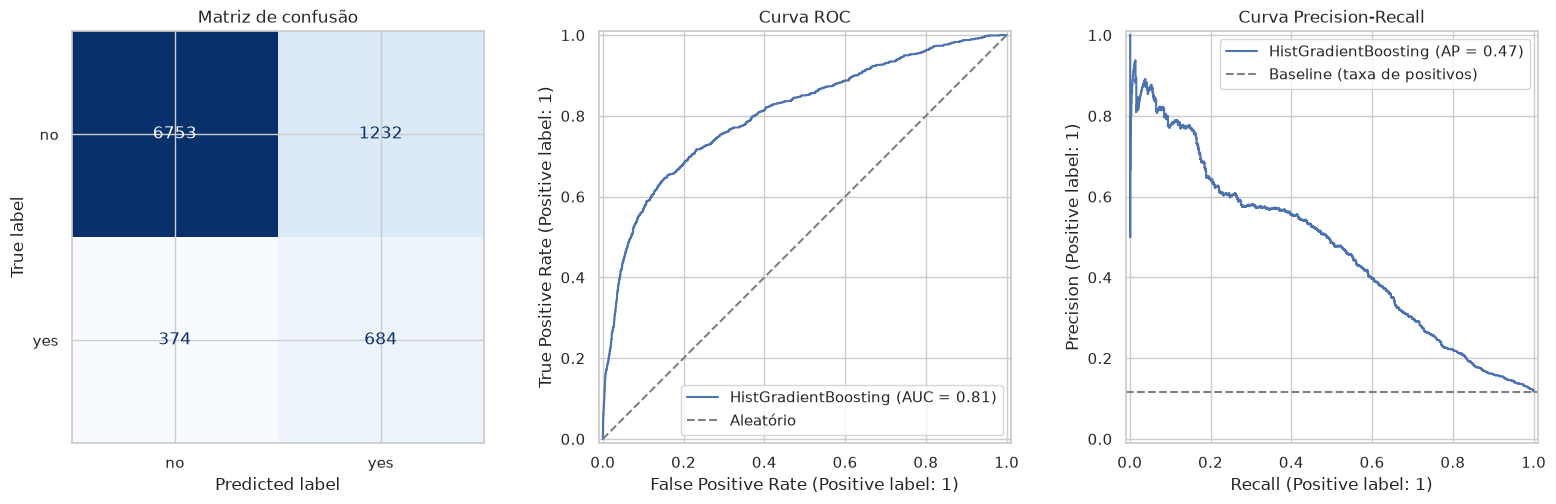

In [24]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    precision_recall_curve,
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["no", "yes"], cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Matriz de confusão")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="HistGradientBoosting")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Aleatório")
axes[1].set_title("Curva ROC")
axes[1].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], name="HistGradientBoosting")
axes[2].axhline(y_test.mean(), linestyle="--", color="grey", label="Baseline (taxa de positivos)")
axes[2].set_title("Curva Precision-Recall")
axes[2].legend()

fig.tight_layout()
plt.show()

O gráfico abaixo mostra precisão, recall e F1 (classe positiva) em função do limiar de decisão — explica o trade-off por trás do limiar padrão de 0,5 usado na 4.1 e antecipa a discussão da tarefa de Uso em Produção (onde limiar vira uma decisão de negócio, não só uma escolha técnica).

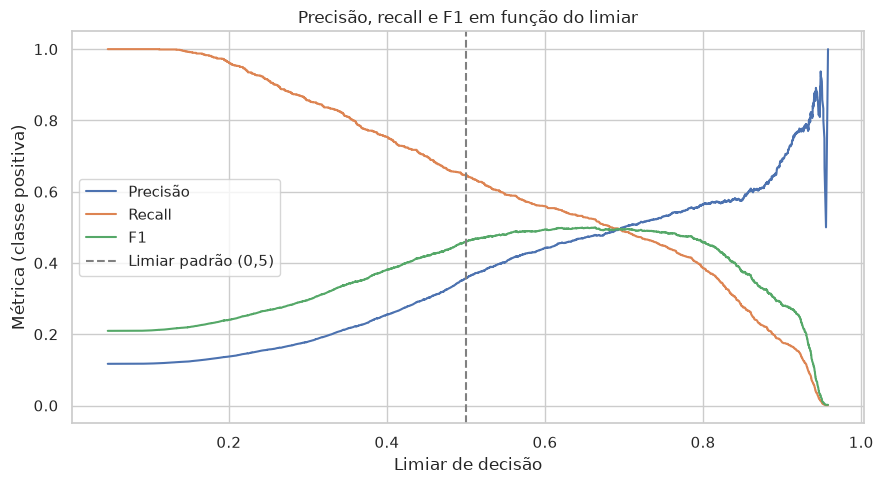

In [25]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label="Precisão")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")
plt.axvline(0.5, linestyle="--", color="grey", label="Limiar padrão (0,5)")
plt.xlabel("Limiar de decisão")
plt.ylabel("Métrica (classe positiva)")
plt.title("Precisão, recall e F1 em função do limiar")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Interpretação e Insights

### 5.1 Recursos mais importantes

Uso `permutation_importance`, não `feature_importances_`: o `HistGradientBoostingClassifier` nem expõe esse atributo nativamente, e mesmo quem expõe (ex. `RandomForestClassifier`) sofre viés a favor de variáveis com muitas categorias — exatamente o caso aqui, com `job`, `poutcome` e `month` expandidas em várias colunas one-hot. `permutation_importance`, calculada no **conjunto de teste** (nunca visto no treino/tuning) com `scoring="roc_auc"` (mesma métrica já usada na Seção 4), mede o impacto real de cada coluna na capacidade preditiva.

Como o `ColumnTransformer` gerou várias colunas dummy para cada variável categórica original, a importância de cada coluna é somada de volta à sua variável original antes do gráfico — para responder "quais **recursos** importam", não "quais colunas dummy importam".

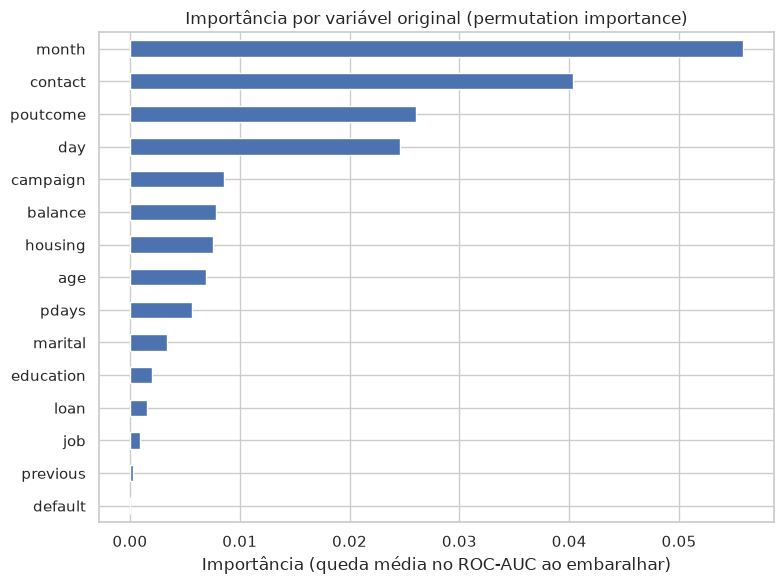

In [26]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_model, X_test_proc, y_test, scoring="roc_auc", n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1
)
perm_importance = pd.Series(perm_result.importances_mean, index=X_test_proc.columns)


def feature_to_original(feature_name, nominal_cols):
    prefix, _, rest = feature_name.partition("__")
    if prefix == "nom":
        return next(c for c in nominal_cols if rest.startswith(c + "_"))
    return rest


feature_origin = pd.Series({f: feature_to_original(f, NOMINAL_COLS) for f in perm_importance.index})
importance_by_feature = perm_importance.groupby(feature_origin).sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance_by_feature.plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importância (queda média no ROC-AUC ao embaralhar)")
plt.title("Importância por variável original (permutation importance)")
plt.tight_layout()
plt.show()

In [27]:
importance_by_feature.to_frame("importância agregada")

,importância agregada
month,0.055852
contact,0.040316
poutcome,0.026062
day,0.024619
campaign,0.008543
balance,0.007870
housing,0.007559
age,0.006961
pdays,0.005653
marital,0.003404


In [28]:
# Granularidade dentro das variáveis nominais: quais categorias específicas mais pesam.
perm_importance.sort_values(ascending=False).head(10).to_frame("importância (colunas transformadas)")

,importância (colunas transformadas)
nom__contact_unknown,0.030048
nom__poutcome_success,0.025923
num__day,0.024619
nom__contact_cellular,0.009955
nom__month_aug,0.009619
num__campaign,0.008543
num__balance,0.007870
nom__month_may,0.007819
bin__housing,0.007559
nom__month_jun,0.007268


**Leitura do resultado:** as variáveis mais importantes para o modelo são `month` (0,056), `contact` (0,040), `poutcome` (0,026) e `day` (0,025) — praticamente empatadas à frente do restante. Isso confirma parte do que a EDA (Seção 1.4) já sugeria (`poutcome`, `contact`), mas com uma diferença importante: **`month`/`day` (timing do contato) pesam mais no modelo do que `job`**, que na EDA parecia relevante (aposentados/estudantes convertiam acima da média) mas aqui contribui muito pouco (0,0009) — sinal de que o efeito de `job` observado na correlação bruta provavelmente é parcialmente explicado por outras variáveis (ex. quem é contatado em determinados meses/canais), não um efeito independente forte. Na granularidade por categoria, `contact_unknown` é a coluna individual mais importante — o modelo aprendeu que a *ausência* de um canal de contato identificado já é, em si, um sinal (associado a campanhas antigas/menos qualificadas, como visto na Seção 1).

### 5.2 Insights acionáveis

**Nota:** `duration` foi excluída do modelo por vazamento de dado (Seções 1.4 e 2) — só é conhecida depois que a ligação termina. Se estivesse incluída, dominaria a importância, mas não seria utilizável para decidir *antes* de ligar, que é o cenário real de produção.

Com base nos recursos mais importantes (5.1) — não só na correlação bruta da EDA —, recomendações acionáveis para a equipe de marketing:

- **Timing do contato (`month`/`day`) é o fator isolado mais importante para o modelo.** Vale revisar o calendário de campanhas com base nos meses de maior conversão identificados na EDA (mar/set/out/dez) em vez de concentrar o esforço no mês de maior volume (maio), que converte abaixo da média.
- **Canal de contato (`contact`) é o segundo fator mais importante**, com o próprio "canal desconhecido" sendo o sinal individual mais forte do modelo — provavelmente um proxy para contatos de campanhas mais antigas/menos qualificadas. Priorizar `contact == "cellular"` e investir em atualizar o cadastro de contato dos clientes sem canal identificado.
- **Recontatar clientes com `poutcome == "success"`** (campanha anterior bem-sucedida): terceiro fator mais importante — sinal claro de propensão a aceitar esse tipo de produto.
- **`job` (tipo de profissão) tem impacto pequeno para o modelo**, apesar de aposentados/estudantes aparecerem com conversão acima da média na EDA (Seção 1.4) — esse efeito parece ser majoritariamente explicado por outras variáveis (timing, canal), não um driver independente forte. Não é uma boa base isolada para segmentação de campanha.
- **Usar a probabilidade prevista para priorizar a lista de contatos, não um corte fixo em 0,5.** O gráfico de limiar da Seção 4.2 mostra o trade-off entre precisão e recall — para uma campanha com capacidade limitada de ligações, ordenar os clientes por probabilidade prevista e contatar os N mais prováveis tende a ser mais eficiente do que aplicar um limiar único.

## 6. Utilização do Modelo em Produção

O roteiro traz um único item aberto aqui ("avaliar como esse modelo poderia ser utilizado em produção"). Para manter o mesmo padrão de subseções focadas das tarefas anteriores, dividi em 4 preocupações que, juntas, respondem a essa pergunta: como o modelo roda (6.1), como a saída vira decisão (6.2), como ele é mantido saudável ao longo do tempo (6.3) e quais são os limites conhecidos (6.4).

### 6.1 Pipeline de inferência para produção

`preprocessor` (Seção 2) e `final_model` (Seção 3) já estão ajustados — combiná-los num único `Pipeline` gera o artefato que de fato seria implantado: recebe dados **brutos** (as mesmas colunas de entrada, sem `duration`) e devolve a probabilidade de conversão, sem exigir que quem consome o modelo replique manualmente o pré-processamento.

In [29]:
import os

import joblib
from sklearn.pipeline import Pipeline

# Preserva nomes de coluna no transform (o modelo foi ajustado com X_train_proc como DataFrame).
preprocessor.set_output(transform="pandas")

production_pipeline = Pipeline([("preprocessor", preprocessor), ("model", final_model)])

sample_raw = X_test.head(5)  # dados brutos, como chegariam em produção (sem pré-processar)
proba_antes = production_pipeline.predict_proba(sample_raw)[:, 1]

os.makedirs("models", exist_ok=True)
joblib.dump(production_pipeline, "models/production_pipeline.joblib")
production_pipeline_recarregado = joblib.load("models/production_pipeline.joblib")
proba_depois = production_pipeline_recarregado.predict_proba(sample_raw)[:, 1]

print("Probabilidades antes de salvar:  ", proba_antes.round(4))
print("Probabilidades após recarregar:  ", proba_depois.round(4))
assert (proba_antes == proba_depois).all(), "Round-trip de serialização não bateu"
print("Round-trip de serialização OK.")

Probabilidades antes de salvar:   [0.1621 0.236  0.2495 0.2339 0.5001]
Probabilidades após recarregar:   [0.1621 0.236  0.2495 0.2339 0.5001]
Round-trip de serialização OK.


Em produção, `models/production_pipeline.joblib` seria o artefato implantado — atrás de um job de *scoring* em lote (mais alinhado ao ritmo de campanhas de telemarketing, que rodam por ciclos, não em tempo real) ou de um endpoint simples. Entrada: colunas cadastrais e de campanha conhecidas **antes** do contato; saída: probabilidade de conversão.

### 6.2 Definição do limiar/priorização como decisão de negócio

O gráfico de precisão/recall/F1 por limiar (Seção 4.2) e o insight da Seção 5.2 já apontavam nessa direção: em vez de um corte fixo de probabilidade, faz mais sentido **ordenar os clientes pela probabilidade prevista e contatar os N mais prováveis**, onde N é definido pela capacidade operacional da campanha — não por uma métrica técnica isolada. A tabela abaixo simula esse cenário para algumas capacidades de campanha.

In [30]:
scored = pd.DataFrame({"y_real": y_test.values, "proba": y_proba}, index=y_test.index)
scored = scored.sort_values("proba", ascending=False)
total_yes = scored["y_real"].sum()

linhas = []
for capacidade in [0.10, 0.20, 0.30]:
    n = int(round(len(scored) * capacidade))
    capturados = scored.head(n)["y_real"].sum()
    linhas.append(
        {
            "capacidade_da_campanha": f"{int(capacidade * 100)}%",
            "clientes_contatados": n,
            "yes_capturados": int(capturados),
            "recall_efetivo": capturados / total_yes,
            "precisao_no_grupo": capturados / n,
        }
    )

pd.DataFrame(linhas)

,capacidade_da_campanha,clientes_contatados,yes_capturados,recall_efetivo,precisao_no_grupo
0,10%,904,476,0.449905,0.526549
1,20%,1809,671,0.634216,0.370923
2,30%,2713,762,0.720227,0.280870


Com 10% de capacidade (904 clientes), a campanha capturaria 45% de todos os "yes" do período, com 53% de acerto no grupo contatado. Em 20% de capacidade, sobe para 63% dos "yes" capturados (37% de acerto); em 30%, 72% dos "yes" (28% de acerto). Fica claro o trade-off: quanto maior a capacidade usada, mais conversões totais são capturadas, mas a taxa de acerto por ligação cai — a equipe de campanha escolhe o ponto de operação de acordo com o custo por ligação e a capacidade real disponível, não o modelo.

### 6.3 Monitoramento e retreinamento

O que vale acompanhar ao longo do tempo, uma vez em produção:

- **Distribuição da probabilidade prevista vs. taxa de conversão realizada**: se a proporção de clientes com alta probabilidade cai, ou se a taxa de conversão real entre os contatados diverge da prevista, é sinal de deriva (*drift*) — o padrão de comportamento dos clientes mudou em relação ao período de treino.
- **ROC-AUC/PR-AUC recalculados** à medida que novos rótulos (resultado real das ligações) chegam, comparando com a linha de base desta entrega (ROC-AUC 0,81, PR-AUC 0,47 — Seção 4.1).
- **Consistência de definição das features** entre o pipeline de coleta em produção e o treino — o risco clássico de *training-serving skew* (ex.: `poutcome`/`pdays` calculados de forma diferente entre o sistema que gera os dados de campanha e o notebook).
- **Cadência de retreinamento** acompanhando o ciclo das campanhas de telemarketing (não em tempo real) — período natural para reavaliar se o modelo ainda captura o padrão de conversão atual.

### 6.4 Limitações e riscos

- **`duration` foi propositalmente excluída** (Seções 1.4/2) para evitar vazamento de dado — não é uma limitação por falta de dado, mas uma escolha deliberada para que o modelo seja utilizável antes da ligação acontecer.
- **Dados históricos de 2008–2010** (`docs/bank-names.txt`), período específico de crise financeira — o padrão de conversão pode não generalizar para outras condições econômicas. Recomenda-se revalidação periódica (ver 6.3) antes de reuso irrestrito.
- **Precisão baixa da classe `yes` no limiar padrão** (0,36, Seção 4.1) — uma lista de contatos gerada por corte fixo teria bastante "ruído" (muitos falsos positivos). Mitigado pela priorização por probabilidade discutida na 6.2.
- **Nenhuma auditoria de viés/fairness foi feita** sobre atributos sensíveis (`age`, `job`, `marital`) — fica registrado como limitação conhecida desta entrega, não resolvida aqui.

---

## Fim do notebook

Com a Seção 6, cobri as 6 tarefas do roteiro do desafio (`docs/Teste_Modelagem_Python.pdf`): EDA → pré-processamento → construção de modelos → avaliação → interpretação e insights → utilização em produção. Decisões e justificativas ficam registradas ao longo do notebook e resumidas no `CLAUDE.md` do repositório. O relatório/apresentação pedido pelo enunciado é entregue à parte, fora deste notebook.